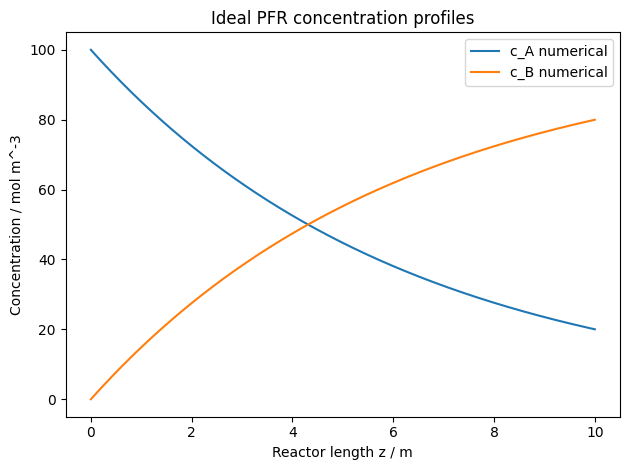

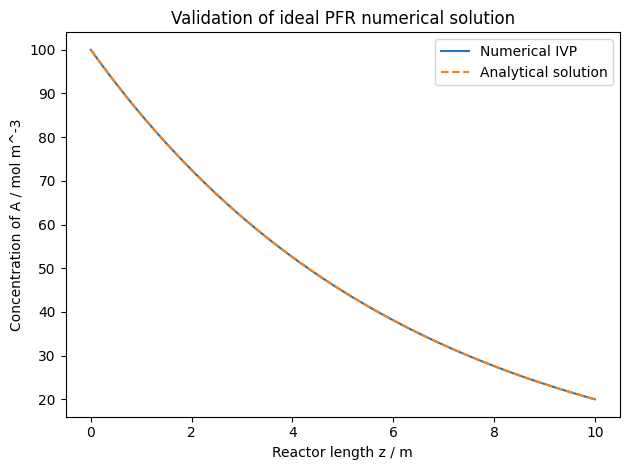

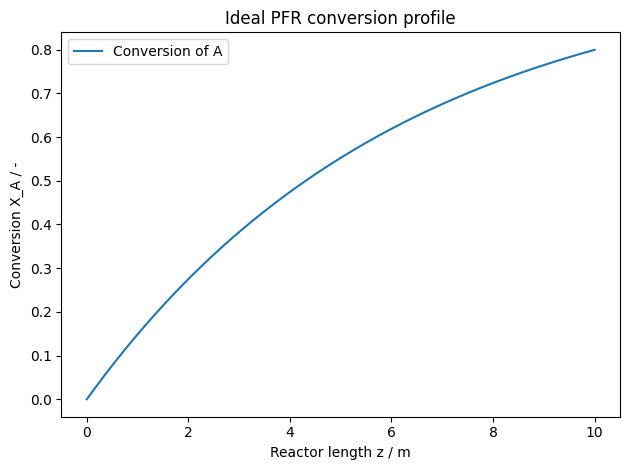

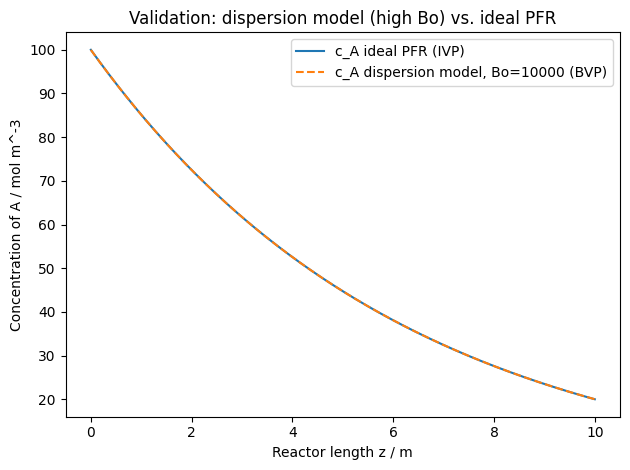

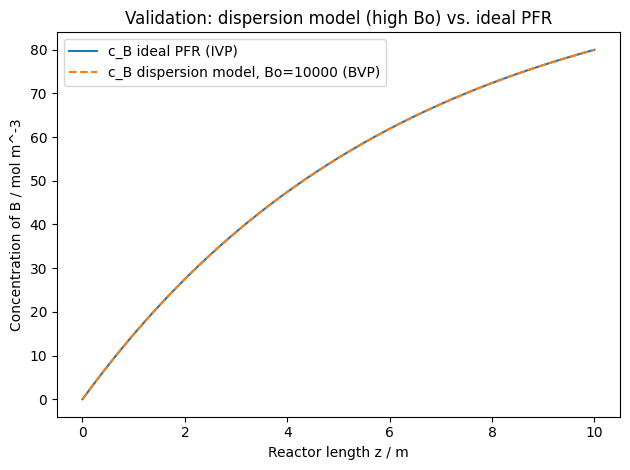

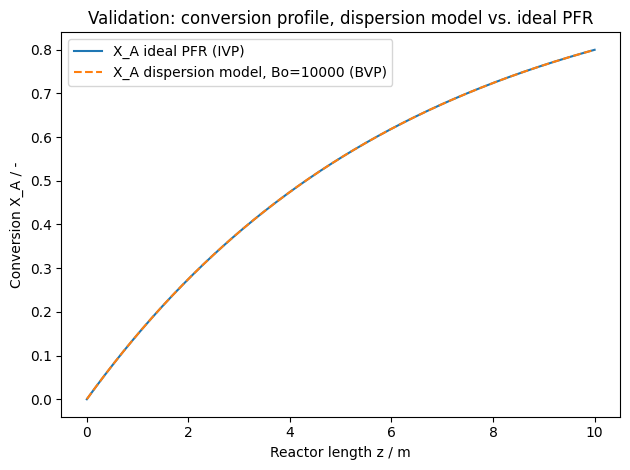

c_A,in (feed)        = 100.0000 mol/m^3
c_A(z=0) (in-reactor) = 99.9839 mol/m^3
Inlet concentration jump = 0.0161 mol/m^3  (0.02%)
Relative difference in outlet conversion: 0.01%
        Bo  c_A(z=0) / mol m^-3  Inlet jump / %
0    100.0            98.441258        1.558742
1   1000.0            99.839666        0.160334
2  10000.0            99.983920        0.016080
Full Bodenstein-number study:
 Bo / -  D_ax / m2 s^-1  c_A(z=0) / mol m^-3  Inlet jump / %  c_A,out / mol m^-3  c_B,out / mol m^-3  X_A,out / -  max |J_disp,A| / mol m^-2 s^-1  z at max |J_disp,A| / m
      5        2.486796            79.621166       20.378834           26.634107           73.365893     0.733659                       25.339001                      0.0
     10        1.243398            87.644337       12.355663           24.047512           75.952488     0.759525                       15.363007                      0.0
     20        0.621699            93.038327        6.961673           22.282345      

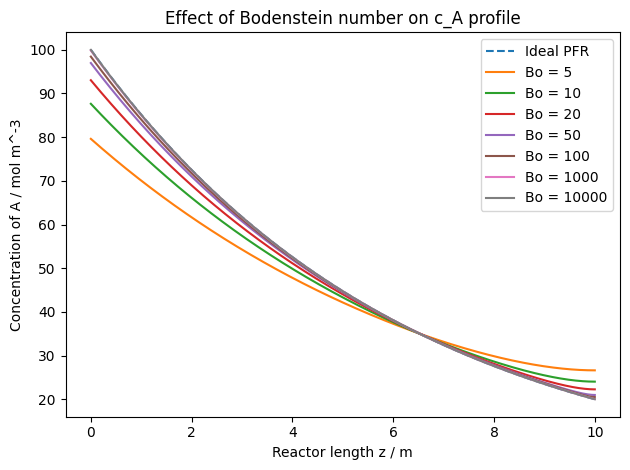

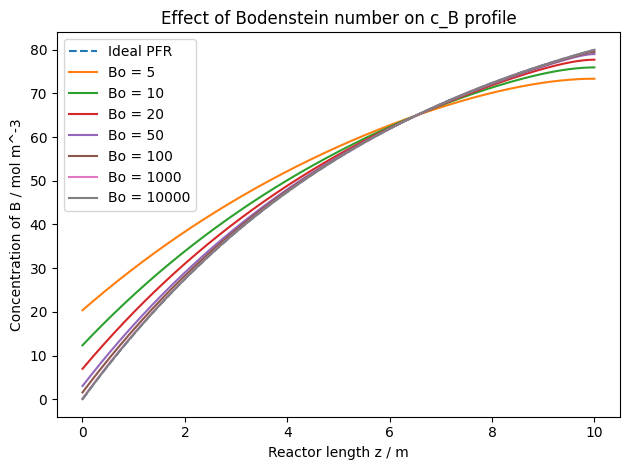

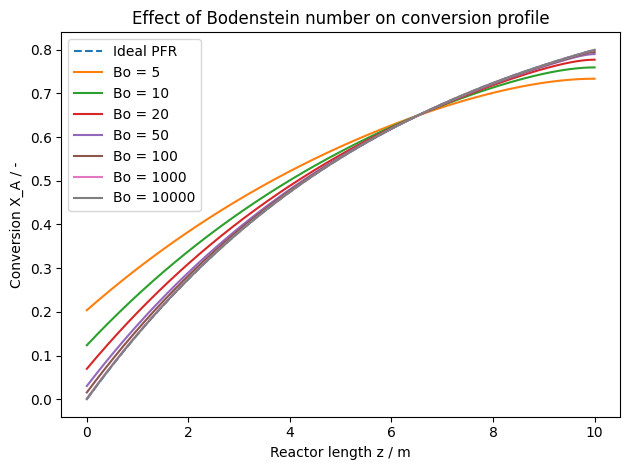

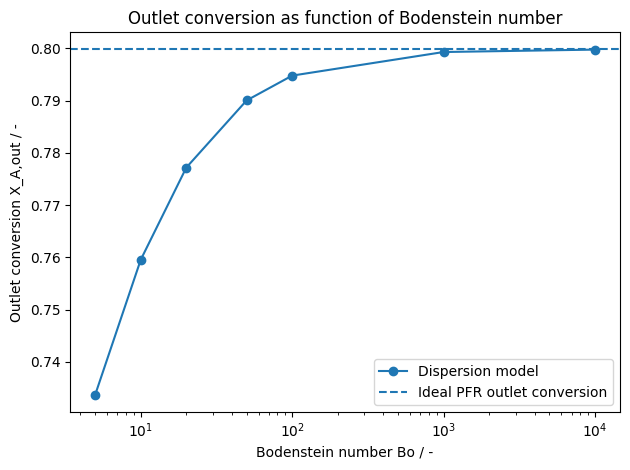

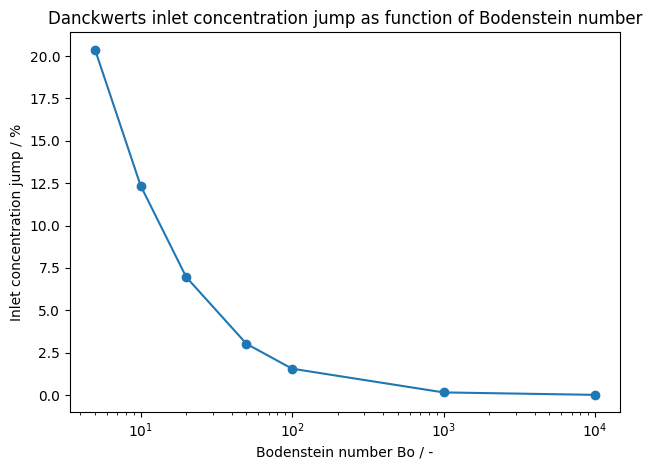

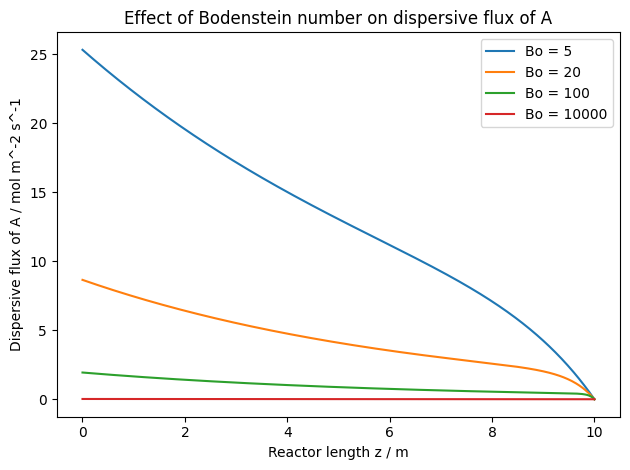

Theoretical and practical boundary cases:
           Case         Mathematical meaning                                                                          Expected reactor behaviour                                                                          Practical interpretation
 Bo -> infinity                    D_ax -> 0                               Axial dispersion disappears and the model approaches ideal plug flow.                                     Very weak backmixing; convection dominates over axial mixing.
        High Bo                   Small D_ax                                          The axial-dispersion model remains close to the ideal PFR.                        Typical of strongly convective tubular reactors with limited axial mixing.
         Low Bo                   Large D_ax Stronger backmixing smooths concentration gradients and causes larger deviation from PFR behaviour.                       Axial mixing becomes important and the reactor becomes less pl

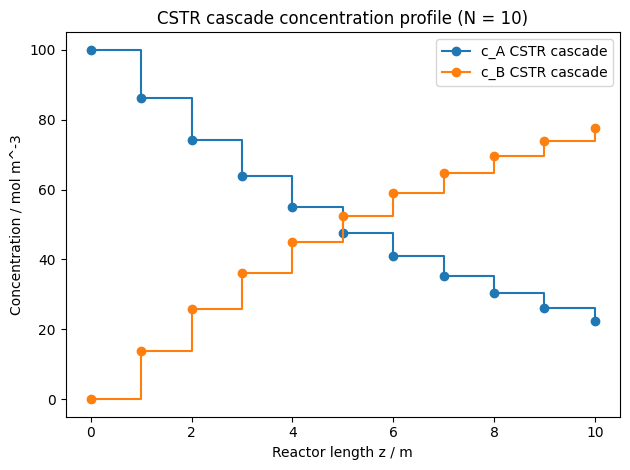

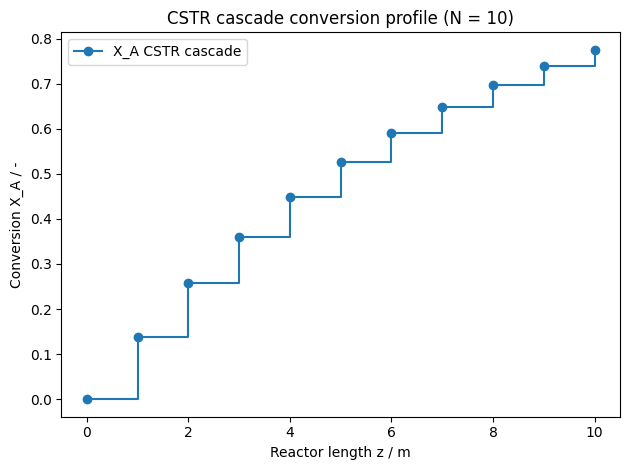

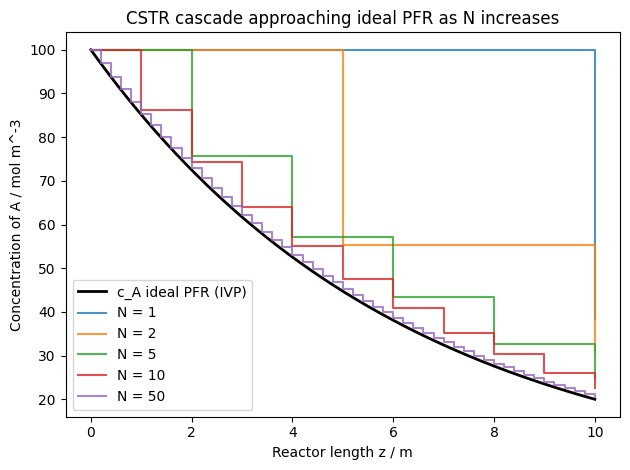

Comparison of CSTR cascade with dispersion model at three distinct points:
 z / m  z/L / -  Bo dispersion / -  N CSTR / -  c_A dispersion / mol m^-3  c_A CSTR cascade / mol m^-3  Difference c_A / mol m^-3  c_B dispersion / mol m^-3  c_B CSTR cascade / mol m^-3  Difference c_B / mol m^-3  X_A dispersion / -  X_A CSTR cascade / -  Difference X_A / -
   2.5     0.25                 20          10                  63.999998                    69.066385                   5.066387                  36.000001                    30.933615                  -5.066387            0.360000              0.309336           -0.050664
   5.0     0.50                 20          10                  44.024871                    47.437340                   3.412468                  55.975128                    52.562660                  -3.412468            0.559751              0.525627           -0.034125
  10.0     1.00                 20          10                  22.282345                    22.5030

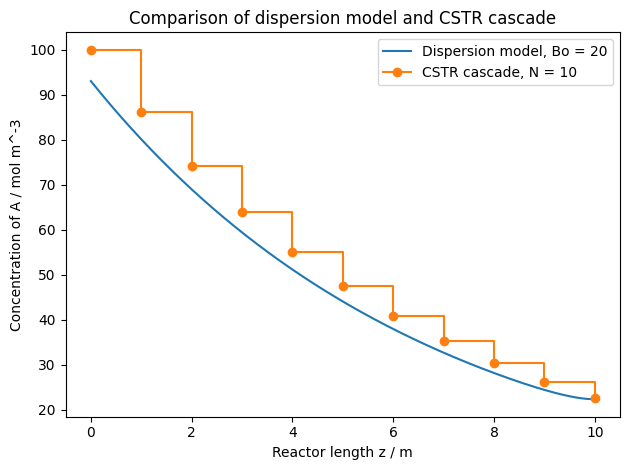

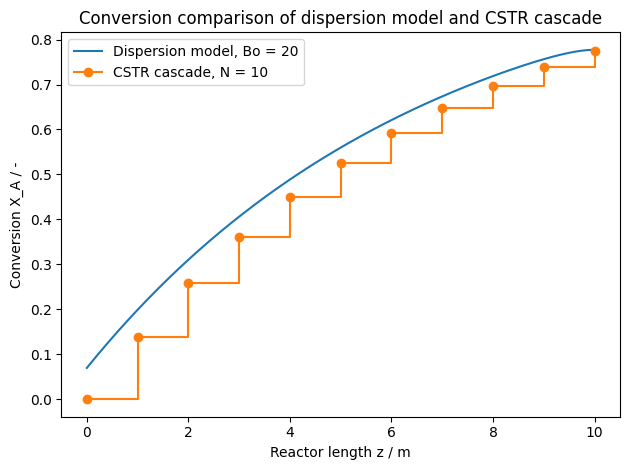

Final model comparison summary:
               Model     Parameter  c_A,out / mol m^-3  c_B,out / mol m^-3  X_A,out / -
       Ideal PFR IVP Bo = infinity           20.018858           79.981142     0.799811
Axial-dispersion BVP        Bo = 5           26.634107           73.365893     0.733659
Axial-dispersion BVP       Bo = 20           22.282345           77.717655     0.777177
Axial-dispersion BVP      Bo = 100           20.522135           79.477865     0.794779
Axial-dispersion BVP    Bo = 10000           20.024036           79.975964     0.799760
        CSTR cascade         N = 1           38.336276           61.663724     0.616637
        CSTR cascade         N = 2           30.719042           69.280958     0.692810
        CSTR cascade         N = 5           24.793455           75.206545     0.752065
        CSTR cascade        N = 10           22.503012           77.496988     0.774970
        CSTR cascade        N = 50           20.532428           79.467572     0.794676


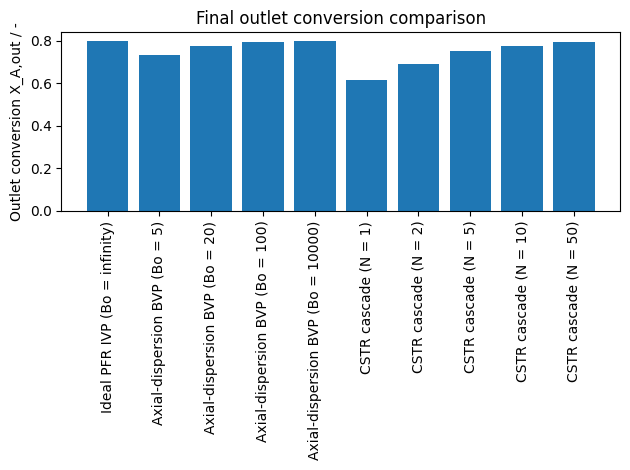

In [1]:
#%%
# Import
import numpy as np
import scipy.integrate as integ 
from scipy.integrate import solve_ivp, solve_bvp 
import matplotlib.pyplot as plt 
import pandas as pd

#%%
# Solver validation

def conversion(c_A, c_A_in):
    """
    Calculate conversion of component A.
    
    Parameters
    ----------
    c_A : float or array
        Local concentration of component A.
    c_A_in : float
        Inlet concentration of component A.
        
    Returns
    -------
    X_A : float or array
        Conversion of component A.
    """
    return (c_A_in - c_A) / c_A_in


# Given reactor and feed data
L = 10.0                       # reactor length, m
d_R = 32e-3                    # reactor diameter, m
d_up = 150e-3                  # upstream pipe diameter, m
V_dot = 1.0e-3                 # volumetric flow rate, m3/s, from 1 L/s
c_A_in = 100.0                 # inlet concentration of A, mol/m3
c_B_in = 0.0                   # inlet concentration of B, mol/m3

# First implementation: first-order kinetics
# This value is selected as a reference value because the task statement does not provide k.
k = 0.2                        # rate constant, s^-1
reaction_order = 1.0

# Cross-sectional areas
A_R = np.pi * d_R**2 / 4
A_up = np.pi * d_up**2 / 4

# Superficial velocities
u = V_dot / A_R
u_up = V_dot / A_up

# Mean residence time in the reactor
tau = L / u

def pfr_ivp_rhs(z, y, k, u):
    """
    Right-hand side of the ideal plug-flow reactor model.

    y[0] = c_A
    y[1] = c_B
    """
    c_A, c_B = y

    r = k * c_A

    dc_A_dz = -r / u
    dc_B_dz = r / u

    return [dc_A_dz, dc_B_dz]


# Axial grid for evaluation
z_eval = np.linspace(0, L, 500)

# Solve ideal PFR model
ivp_solution = solve_ivp(
    fun=lambda z, y: pfr_ivp_rhs(z, y, k, u),
    t_span=(0, L),
    y0=[c_A_in, c_B_in],
    t_eval=z_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-11
)

if not ivp_solution.success:
    raise RuntimeError(ivp_solution.message)

# Store results
pfr_df = pd.DataFrame({
    "z / m": ivp_solution.t,
    "c_A / mol m^-3": ivp_solution.y[0],
    "c_B / mol m^-3": ivp_solution.y[1],
})

pfr_df["X_A / -"] = conversion(pfr_df["c_A / mol m^-3"], c_A_in)

# Analytical solution
pfr_df["c_A analytical / mol m^-3"] = c_A_in * np.exp(-k * pfr_df["z / m"] / u)
pfr_df["X_A analytical / -"] = conversion(pfr_df["c_A analytical / mol m^-3"], c_A_in)

# Error between numerical and analytical solution
max_error_cA = np.max(
    np.abs(pfr_df["c_A / mol m^-3"] - pfr_df["c_A analytical / mol m^-3"])
)

max_error_X = np.max(
    np.abs(pfr_df["X_A / -"] - pfr_df["X_A analytical / -"])
)

# Summary table
pfr_summary = pd.DataFrame([
    {
        "Model": "Ideal PFR IVP",
        "Residence time / s": tau,
        "c_A,out / mol m^-3": pfr_df["c_A / mol m^-3"].iloc[-1],
        "c_B,out / mol m^-3": pfr_df["c_B / mol m^-3"].iloc[-1],
        "X_A,out / -": pfr_df["X_A / -"].iloc[-1],
        "Max. error c_A / mol m^-3": max_error_cA,
        "Max. error X_A / -": max_error_X,
    }
])


# Concentration profiles
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A numerical"
)
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    label="c_B numerical"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration / mol m^-3")
plt.title("Ideal PFR concentration profiles")
plt.legend()
plt.tight_layout()
plt.show()

# Numerical vs analytical validation
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="Numerical IVP"
)
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A analytical / mol m^-3"],
    "--",
    label="Analytical solution"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Validation of ideal PFR numerical solution")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion profile
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    label="Conversion of A"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Ideal PFR conversion profile")
plt.legend()
plt.tight_layout()
plt.show()


# %%
# Boundary value problem

def dispersion_bvp_rhs(z, y, k, u, D_ax):
    """
    Right-hand side of the axial-dispersion model, first-order system.

    y[0] = c_A
    y[1] = dc_A/dz
    y[2] = c_B
    y[3] = dc_B/dz
    """
    c_A, dcA_dz, c_B, dcB_dz = y

    # from  u*dcA/dz = D_ax*d2cA/dz2 - k*c_A
    d2cA_dz2 = (u * dcA_dz + k * c_A) / D_ax

    # from  u*dcB/dz = D_ax*d2cB/dz2 + k*c_A
    d2cB_dz2 = (u * dcB_dz - k * c_A) / D_ax

    return np.vstack((dcA_dz, d2cA_dz2, dcB_dz, d2cB_dz2))


def dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax):
    """
    Danckwerts boundary conditions at z=0 and z=L for both species.
    """
    cA0, dcA0, cB0, dcB0 = ya   # state at z=0
    cAL, dcAL, cBL, dcBL = yb   # state at z=L

    # z = 0: Danckwerts inlet condition
    res_A0 = cA0 - (D_ax / u) * dcA0 - c_A_in
    res_B0 = cB0 - (D_ax / u) * dcB0 - c_B_in

    # z = L: zero-gradient outlet condition
    res_AL = dcAL
    res_BL = dcBL

    return np.array([res_A0, res_AL, res_B0, res_BL])


# Choose a high Bo for the validation run (weak dispersion -> should match IVP)
Bo_high = 1e4
D_ax = u * L / Bo_high

# Mesh and initial guess
z_mesh = np.linspace(0, L, 200)
y_guess = np.zeros((4, z_mesh.size))
y_guess[0] = c_A_in   # rough guess: c_A starts near inlet value
y_guess[2] = 0.0      # rough guess: c_B starts at 0

bvp_solution = solve_bvp(
    lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax),
    lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax),
    z_mesh,
    y_guess
)

if not bvp_solution.success:
    raise RuntimeError(bvp_solution.message)

z_plot = np.linspace(0, L, 500)
y_plot = bvp_solution.sol(z_plot)
c_A_bvp = y_plot[0]
c_B_bvp = y_plot[2]

# Comparison: axial-dispersion BVP (high Bo) vs ideal PFR IVP
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A ideal PFR (IVP)"
)
plt.plot(
    z_plot,
    c_A_bvp,
    "--",
    label=f"c_A dispersion model, Bo={Bo_high:.0f} (BVP)"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Validation: dispersion model (high Bo) vs. ideal PFR")
plt.legend()
plt.tight_layout()
plt.show()

# Same comparison for component B
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    label="c_B ideal PFR (IVP)"
)
plt.plot(
    z_plot,
    c_B_bvp,
    "--",
    label=f"c_B dispersion model, Bo={Bo_high:.0f} (BVP)"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of B / mol m^-3")
plt.title("Validation: dispersion model (high Bo) vs. ideal PFR")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion comparison + quantitative error at outlet
X_A_bvp = conversion(c_A_bvp, c_A_in)

plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    label="X_A ideal PFR (IVP)"
)
plt.plot(
    z_plot,
    X_A_bvp,
    "--",
    label=f"X_A dispersion model, Bo={Bo_high:.0f} (BVP)"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Validation: conversion profile, dispersion model vs. ideal PFR")
plt.legend()
plt.tight_layout()
plt.show()

# Quantitative check at the outlet
X_A_out_ivp = pfr_df["X_A / -"].iloc[-1]
X_A_out_bvp = X_A_bvp[-1]
rel_diff = abs(X_A_out_bvp - X_A_out_ivp) / X_A_out_ivp

validation_summary = pd.DataFrame([{
    "Model": "Ideal PFR (IVP)",
    "Bo": np.inf,
    "X_A,out / -": X_A_out_ivp,
}, {
    "Model": "Dispersion model (BVP)",
    "Bo": Bo_high,
    "X_A,out / -": X_A_out_bvp,
}])

c_A_inlet_bvp = bvp_solution.sol(0)[0]   # c_A at z = 0, inside the reactor
c_A_jump = c_A_in - c_A_inlet_bvp
c_A_jump_rel = c_A_jump / c_A_in

print(f"c_A,in (feed)        = {c_A_in:.4f} mol/m^3")
print(f"c_A(z=0) (in-reactor) = {c_A_inlet_bvp:.4f} mol/m^3")
print(f"Inlet concentration jump = {c_A_jump:.4f} mol/m^3  ({c_A_jump_rel:.2%})")
print(f"Relative difference in outlet conversion: {rel_diff:.2%}")


#%%
# Differences in inlet concentration jump for different Bo numbers

bo_values = [1e2, 1e3, 1e4]
jump_records = []

for Bo in bo_values:
    D_ax_i = u * L / Bo
    sol_i = solve_bvp(
        lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax_i),
        lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax_i),
        z_mesh, y_guess
    )

    c_A0_i = sol_i.sol(0)[0]
    jump_records.append({
        "Bo": Bo,
        "c_A(z=0) / mol m^-3": c_A0_i,
        "Inlet jump / %": (c_A_in - c_A0_i) / c_A_in * 100
    })

print(pd.DataFrame(jump_records))


#%%
# Full Bodenstein-number study for axial dispersion and backmixing

bo_study_values = [5, 10, 20, 50, 100, 1000, 10000]
bo_results = {}
bo_summary_records = []

z_bvp_study = np.linspace(0, L, 500)

for Bo in bo_study_values:
    D_ax_i = u * L / Bo

    z_mesh_i = np.linspace(0, L, 300)

    c_A_guess = c_A_in * np.exp(-k * z_mesh_i / u)
    dcA_dz_guess = -(k / u) * c_A_guess
    c_B_guess = c_B_in + c_A_in - c_A_guess
    dcB_dz_guess = -dcA_dz_guess

    y_guess_i = np.vstack((c_A_guess, dcA_dz_guess, c_B_guess, dcB_dz_guess))

    sol_i = solve_bvp(
        lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax_i),
        lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax_i),
        z_mesh_i,
        y_guess_i,
        tol=1e-5,
        max_nodes=20000
    )

    if not sol_i.success:
        print(f"BVP failed for Bo = {Bo}: {sol_i.message}")
        continue

    y_i = sol_i.sol(z_bvp_study)

    c_A_i = y_i[0]
    dcA_dz_i = y_i[1]
    c_B_i = y_i[2]
    dcB_dz_i = y_i[3]
    X_A_i = conversion(c_A_i, c_A_in)

    c_A0_i = sol_i.sol(0)[0]
    inlet_jump_i = c_A_in - c_A0_i
    inlet_jump_percent_i = inlet_jump_i / c_A_in * 100

    J_disp_A_i = -D_ax_i * dcA_dz_i
    max_abs_J_disp_A_i = np.max(np.abs(J_disp_A_i))
    z_max_J_i = z_bvp_study[np.argmax(np.abs(J_disp_A_i))]

    bo_results[Bo] = {
        "solution": sol_i,
        "D_ax": D_ax_i,
        "z": z_bvp_study,
        "c_A": c_A_i,
        "dcA_dz": dcA_dz_i,
        "c_B": c_B_i,
        "dcB_dz": dcB_dz_i,
        "X_A": X_A_i,
        "J_disp_A": J_disp_A_i
    }

    bo_summary_records.append({
        "Bo / -": Bo,
        "D_ax / m2 s^-1": D_ax_i,
        "c_A(z=0) / mol m^-3": c_A0_i,
        "Inlet jump / %": inlet_jump_percent_i,
        "c_A,out / mol m^-3": c_A_i[-1],
        "c_B,out / mol m^-3": c_B_i[-1],
        "X_A,out / -": X_A_i[-1],
        "max |J_disp,A| / mol m^-2 s^-1": max_abs_J_disp_A_i,
        "z at max |J_disp,A| / m": z_max_J_i
    })

bo_summary_df = pd.DataFrame(bo_summary_records)

print("Full Bodenstein-number study:")
print(bo_summary_df.to_string(index=False))

# Concentration of A for different Bo
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    "--",
    label="Ideal PFR"
)

for Bo in bo_study_values:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["c_A"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Effect of Bodenstein number on c_A profile")
plt.legend()
plt.tight_layout()
plt.show()

# Concentration of B for different Bo
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_B / mol m^-3"],
    "--",
    label="Ideal PFR"
)

for Bo in bo_study_values:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["c_B"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of B / mol m^-3")
plt.title("Effect of Bodenstein number on c_B profile")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion for different Bo
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["X_A / -"],
    "--",
    label="Ideal PFR"
)

for Bo in bo_study_values:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["X_A"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Effect of Bodenstein number on conversion profile")
plt.legend()
plt.tight_layout()
plt.show()

# Outlet conversion as function of Bo
plt.figure()
plt.semilogx(
    bo_summary_df["Bo / -"],
    bo_summary_df["X_A,out / -"],
    marker="o",
    label="Dispersion model"
)
plt.axhline(
    y=pfr_df["X_A / -"].iloc[-1],
    linestyle="--",
    label="Ideal PFR outlet conversion"
)
plt.xlabel("Bodenstein number Bo / -")
plt.ylabel("Outlet conversion X_A,out / -")
plt.title("Outlet conversion as function of Bodenstein number")
plt.legend()
plt.tight_layout()
plt.show()

# Inlet concentration jump as function of Bo
plt.figure()
plt.semilogx(
    bo_summary_df["Bo / -"],
    bo_summary_df["Inlet jump / %"],
    marker="o"
)
plt.xlabel("Bodenstein number Bo / -")
plt.ylabel("Inlet concentration jump / %")
plt.title("Danckwerts inlet concentration jump as function of Bodenstein number")
plt.tight_layout()
plt.show()

# Dispersive flux of A for selected Bo values
selected_bo_flux = [5, 20, 100, 10000]

plt.figure()

for Bo in selected_bo_flux:
    if Bo in bo_results:
        plt.plot(
            bo_results[Bo]["z"],
            bo_results[Bo]["J_disp_A"],
            label=f"Bo = {Bo:g}"
        )

plt.xlabel("Reactor length z / m")
plt.ylabel("Dispersive flux of A / mol m^-2 s^-1")
plt.title("Effect of Bodenstein number on dispersive flux of A")
plt.legend()
plt.tight_layout()
plt.show()


#%%
# Theoretical and practical boundary cases

boundary_cases_df = pd.DataFrame([
    {
        "Case": "Bo -> infinity",
        "Mathematical meaning": "D_ax -> 0",
        "Expected reactor behaviour": "Axial dispersion disappears and the model approaches ideal plug flow.",
        "Practical interpretation": "Very weak backmixing; convection dominates over axial mixing."
    },
    {
        "Case": "High Bo",
        "Mathematical meaning": "Small D_ax",
        "Expected reactor behaviour": "The axial-dispersion model remains close to the ideal PFR.",
        "Practical interpretation": "Typical of strongly convective tubular reactors with limited axial mixing."
    },
    {
        "Case": "Low Bo",
        "Mathematical meaning": "Large D_ax",
        "Expected reactor behaviour": "Stronger backmixing smooths concentration gradients and causes larger deviation from PFR behaviour.",
        "Practical interpretation": "Axial mixing becomes important and the reactor becomes less plug-flow-like."
    },
    {
        "Case": "Very large D_ax",
        "Mathematical meaning": "Very strong axial dispersion",
        "Expected reactor behaviour": "The reactor tends toward mixed-reactor-like behaviour.",
        "Practical interpretation": "The axial concentration profile becomes flatter and the reactor behaves more like a mixed system."
    },
    {
        "Case": "D_ax -> 0",
        "Mathematical meaning": "No dispersion term",
        "Expected reactor behaviour": "The second derivative term disappears and the ideal PFR balance is recovered.",
        "Practical interpretation": "This is the theoretical plug-flow limit."
    }
])

print("Theoretical and practical boundary cases:")
print(boundary_cases_df.to_string(index=False))


#%%
# CSTR cascade

def cstr_cascade(N, c_A_in, c_B_in, k, tau):
    """
    Steady-state CSTR cascade with N equal tanks, first-order kinetics.

    Returns arrays of c_A, c_B at the outlet of each tank (length N+1,
    including the feed as stage 0).
    """
    tau_i = tau / N

    c_A = np.zeros(N + 1)
    c_B = np.zeros(N + 1)
    c_A[0] = c_A_in
    c_B[0] = c_B_in

    for i in range(1, N + 1):
        c_A[i] = c_A[i-1] / (1 + k * tau_i)
        c_B[i] = c_B[i-1] + (c_A[i-1] - c_A[i])   # mass balance: whatever A lost, B gained

    return c_A, c_B


N = 10
c_A_cascade, c_B_cascade = cstr_cascade(N, c_A_in, c_B_in, k, tau)

# Position each tank's outlet at its physical location along the reactor
z_cascade = np.linspace(0, L, N + 1)

# CSTR cascade concentration profile
plt.figure()
plt.step(
    z_cascade,
    c_A_cascade,
    where="post",
    marker="o",
    label="c_A CSTR cascade"
)
plt.step(
    z_cascade,
    c_B_cascade,
    where="post",
    marker="o",
    label="c_B CSTR cascade"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration / mol m^-3")
plt.title(f"CSTR cascade concentration profile (N = {N})")
plt.legend()
plt.tight_layout()
plt.show()

# Conversion profile
X_A_cascade = conversion(c_A_cascade, c_A_in)

plt.figure()
plt.step(
    z_cascade,
    X_A_cascade,
    where="post",
    marker="o",
    label="X_A CSTR cascade"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title(f"CSTR cascade conversion profile (N = {N})")
plt.legend()
plt.tight_layout()
plt.show()

# Effect of N: cascade approaching plug-flow behaviour
plt.figure()
plt.plot(
    pfr_df["z / m"],
    pfr_df["c_A / mol m^-3"],
    label="c_A ideal PFR (IVP)",
    color="black",
    linewidth=2
)

for N_i in [1, 2, 5, 10, 50]:
    c_A_i, _ = cstr_cascade(N_i, c_A_in, c_B_in, k, tau)
    z_i = np.linspace(0, L, N_i + 1)
    plt.step(
        z_i,
        c_A_i,
        where="post",
        label=f"N = {N_i}",
        alpha=0.8
    )

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("CSTR cascade approaching ideal PFR as N increases")
plt.legend()
plt.tight_layout()
plt.show()


#%%
# Comparison of CSTR cascade with dispersion model at three distinct points

N_compare = 10
Bo_compare = 2 * N_compare

c_A_cascade_compare, c_B_cascade_compare = cstr_cascade(
    N_compare,
    c_A_in,
    c_B_in,
    k,
    tau
)

z_cascade_compare = np.linspace(0, L, N_compare + 1)
X_A_cascade_compare = conversion(c_A_cascade_compare, c_A_in)

if Bo_compare not in bo_results:
    D_ax_compare = u * L / Bo_compare

    z_mesh_compare = np.linspace(0, L, 300)

    c_A_guess = c_A_in * np.exp(-k * z_mesh_compare / u)
    dcA_dz_guess = -(k / u) * c_A_guess
    c_B_guess = c_B_in + c_A_in - c_A_guess
    dcB_dz_guess = -dcA_dz_guess

    y_guess_compare = np.vstack((c_A_guess, dcA_dz_guess, c_B_guess, dcB_dz_guess))

    sol_compare = solve_bvp(
        lambda z, y: dispersion_bvp_rhs(z, y, k, u, D_ax_compare),
        lambda ya, yb: dispersion_bc(ya, yb, c_A_in, c_B_in, u, D_ax_compare),
        z_mesh_compare,
        y_guess_compare,
        tol=1e-5,
        max_nodes=20000
    )

    if not sol_compare.success:
        raise RuntimeError(f"BVP failed for Bo = {Bo_compare}: {sol_compare.message}")

    z_compare = np.linspace(0, L, 500)
    y_compare = sol_compare.sol(z_compare)

    bo_results[Bo_compare] = {
        "solution": sol_compare,
        "D_ax": D_ax_compare,
        "z": z_compare,
        "c_A": y_compare[0],
        "dcA_dz": y_compare[1],
        "c_B": y_compare[2],
        "dcB_dz": y_compare[3],
        "X_A": conversion(y_compare[0], c_A_in),
        "J_disp_A": -D_ax_compare * y_compare[1]
    }

comparison_positions = [0.25 * L, 0.50 * L, L]
cstr_dispersion_comparison_records = []

for z_pos in comparison_positions:
    c_A_disp_pos = np.interp(
        z_pos,
        bo_results[Bo_compare]["z"],
        bo_results[Bo_compare]["c_A"]
    )

    c_B_disp_pos = np.interp(
        z_pos,
        bo_results[Bo_compare]["z"],
        bo_results[Bo_compare]["c_B"]
    )

    X_A_disp_pos = np.interp(
        z_pos,
        bo_results[Bo_compare]["z"],
        bo_results[Bo_compare]["X_A"]
    )

    c_A_cstr_pos = np.interp(
        z_pos,
        z_cascade_compare,
        c_A_cascade_compare
    )

    c_B_cstr_pos = np.interp(
        z_pos,
        z_cascade_compare,
        c_B_cascade_compare
    )

    X_A_cstr_pos = np.interp(
        z_pos,
        z_cascade_compare,
        X_A_cascade_compare
    )

    cstr_dispersion_comparison_records.append({
        "z / m": z_pos,
        "z/L / -": z_pos / L,
        "Bo dispersion / -": Bo_compare,
        "N CSTR / -": N_compare,
        "c_A dispersion / mol m^-3": c_A_disp_pos,
        "c_A CSTR cascade / mol m^-3": c_A_cstr_pos,
        "Difference c_A / mol m^-3": c_A_cstr_pos - c_A_disp_pos,
        "c_B dispersion / mol m^-3": c_B_disp_pos,
        "c_B CSTR cascade / mol m^-3": c_B_cstr_pos,
        "Difference c_B / mol m^-3": c_B_cstr_pos - c_B_disp_pos,
        "X_A dispersion / -": X_A_disp_pos,
        "X_A CSTR cascade / -": X_A_cstr_pos,
        "Difference X_A / -": X_A_cstr_pos - X_A_disp_pos
    })

cstr_dispersion_comparison_df = pd.DataFrame(cstr_dispersion_comparison_records)

print("Comparison of CSTR cascade with dispersion model at three distinct points:")
print(cstr_dispersion_comparison_df.to_string(index=False))

# Plot comparison of c_A profiles
plt.figure()
plt.plot(
    bo_results[Bo_compare]["z"],
    bo_results[Bo_compare]["c_A"],
    label=f"Dispersion model, Bo = {Bo_compare}"
)
plt.step(
    z_cascade_compare,
    c_A_cascade_compare,
    where="post",
    marker="o",
    label=f"CSTR cascade, N = {N_compare}"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration of A / mol m^-3")
plt.title("Comparison of dispersion model and CSTR cascade")
plt.legend()
plt.tight_layout()
plt.show()

# Plot comparison of conversion profiles
plt.figure()
plt.plot(
    bo_results[Bo_compare]["z"],
    bo_results[Bo_compare]["X_A"],
    label=f"Dispersion model, Bo = {Bo_compare}"
)
plt.step(
    z_cascade_compare,
    X_A_cascade_compare,
    where="post",
    marker="o",
    label=f"CSTR cascade, N = {N_compare}"
)
plt.xlabel("Reactor length z / m")
plt.ylabel("Conversion X_A / -")
plt.title("Conversion comparison of dispersion model and CSTR cascade")
plt.legend()
plt.tight_layout()
plt.show()


#%%
# Final summary table

final_summary_records = []

final_summary_records.append({
    "Model": "Ideal PFR IVP",
    "Parameter": "Bo = infinity",
    "c_A,out / mol m^-3": pfr_df["c_A / mol m^-3"].iloc[-1],
    "c_B,out / mol m^-3": pfr_df["c_B / mol m^-3"].iloc[-1],
    "X_A,out / -": pfr_df["X_A / -"].iloc[-1]
})

for Bo in [5, 20, 100, 10000]:
    if Bo in bo_results:
        final_summary_records.append({
            "Model": "Axial-dispersion BVP",
            "Parameter": f"Bo = {Bo:g}",
            "c_A,out / mol m^-3": bo_results[Bo]["c_A"][-1],
            "c_B,out / mol m^-3": bo_results[Bo]["c_B"][-1],
            "X_A,out / -": bo_results[Bo]["X_A"][-1]
        })

for N_i in [1, 2, 5, 10, 50]:
    c_A_i, c_B_i = cstr_cascade(N_i, c_A_in, c_B_in, k, tau)
    X_A_i = conversion(c_A_i, c_A_in)

    final_summary_records.append({
        "Model": "CSTR cascade",
        "Parameter": f"N = {N_i}",
        "c_A,out / mol m^-3": c_A_i[-1],
        "c_B,out / mol m^-3": c_B_i[-1],
        "X_A,out / -": X_A_i[-1]
    })

final_summary_df = pd.DataFrame(final_summary_records)

print("Final model comparison summary:")
print(final_summary_df.to_string(index=False))

# Final outlet conversion comparison plot
plt.figure()

plot_labels = final_summary_df["Model"] + " (" + final_summary_df["Parameter"] + ")"

plt.bar(
    np.arange(len(final_summary_df)),
    final_summary_df["X_A,out / -"]
)

plt.xticks(
    np.arange(len(final_summary_df)),
    plot_labels,
    rotation=90
)

plt.ylabel("Outlet conversion X_A,out / -")
plt.title("Final outlet conversion comparison")
plt.tight_layout()
plt.show()